In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exercise 02.1

aggiungere a lato del plot le funzioni dell importance sampling paragonate col coseno e plot degli errori



In [84]:
integral=pd.read_csv('data/cosinteg_M1000000.csv')
df_is=pd.read_csv('data/cosinteg_M1000000_is.csv')



It's clearly visible that using the first order taylor expansion of the cos function the convergence is faster with a minor variance

due parole in piu su come ho scelto dove centrare taylor

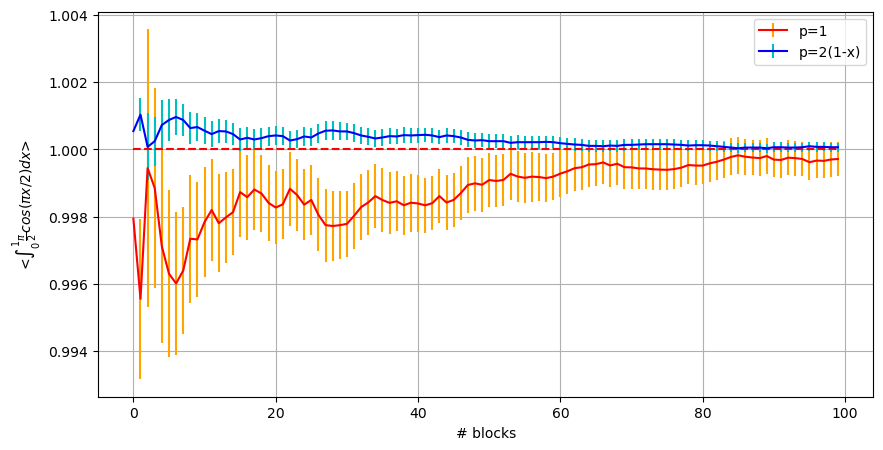

In [85]:
plt.figure(figsize=(10,5))
plt.errorbar(integral.index, integral.avg, color='r', ecolor='orange', yerr=integral.err, label='p=1')
plt.errorbar(df_is.index, df_is.avg, yerr=df_is.err, label='p=2(1-x)', color='b', ecolor='c')
plt.hlines(1, 0, df_is.index[-1], linestyles='--', colors='r')
plt.legend()
plt.ylabel(r'<$\int_0^1 \frac{\pi}{2} cos(\pi x/2 )dx$>')
plt.xlabel('# blocks')


plt.grid(True)
plt.show()


# Exercise 02.2: Random Walk


## Code implementation
I implemented 2 classes Random Walk (lattice and continuous) 

```C++
class RW_lattice
{
	public:
		//constructor
		RW_lattice(); //default constructor
		RW_lattice(double a, int* seed);
		
		//destructor
		~RW_lattice(){};
		
		//methods
		vector<double> get_pos () const{return pos;};
		int get_nstep() const {return step;};
		//reset the position and number of steps
		void reset_rw(); 
		
		//make a step in random direction and 
		// verse on the lattice
		void make_step();
		
	protected:
		double m_a;
		vector<double> pos=vector <double>(3, 0.0);
		
		Random rnd;
		int step;
		
		
		double verse_increment();
		vector<double> dir_increment(
			double p_x=1/3., 
			double p_y=1/3.,
			double p_z=1/3.
		);
};


```

The continuous version has an identical header, the difference are in the implementation inside the step functions.

Both of classes have:
```C++

void make_step()
{
	//select direction x | y | z
	vector <double> stepv = dir_increment();		
		
	// select verse Rx | Lx
	double verse=verse_increment();	// return sign *m_a
	
	// generate step of lenght a and update position and step number
	for(int i=0; i<3; ++i)
	{
		pos[i]+=stepv[i]*verse;
	}
	
	step+=1;
}
```

But for the lattice only step along the 3 axis direction are avaiable
```C++
//return copy but 3dim not heavy
vector<double> RW_lattice::dir_increment(double p_x, double p_y, double p_z)
{
	double r = rnd.Rannyu();
	if(r<p_x)
		return vector<double> {1., 0., 0.};
	else if(r<p_x+p_y)
		return vector<double> {0., 1., 0.};
	else
		return vector<double> {0., 0., 1.};
		
	
}

```

While the contiuous version make sampling on the sphere:

```C++
//return copy but 3dim not heavy
vector<double> RW_continuous::dir_increment(double p_x, double p_y, double p_z)
{
	double phi=rnd.Rannyu();
	double r = rnd.Rannyu();
	double theta=acos(1-2*r);

	return vector<double> {
		sin(theta)*cos(phi),
		sin(theta)*sin(phi),
		cos(theta)
	};
	
	
}

```


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

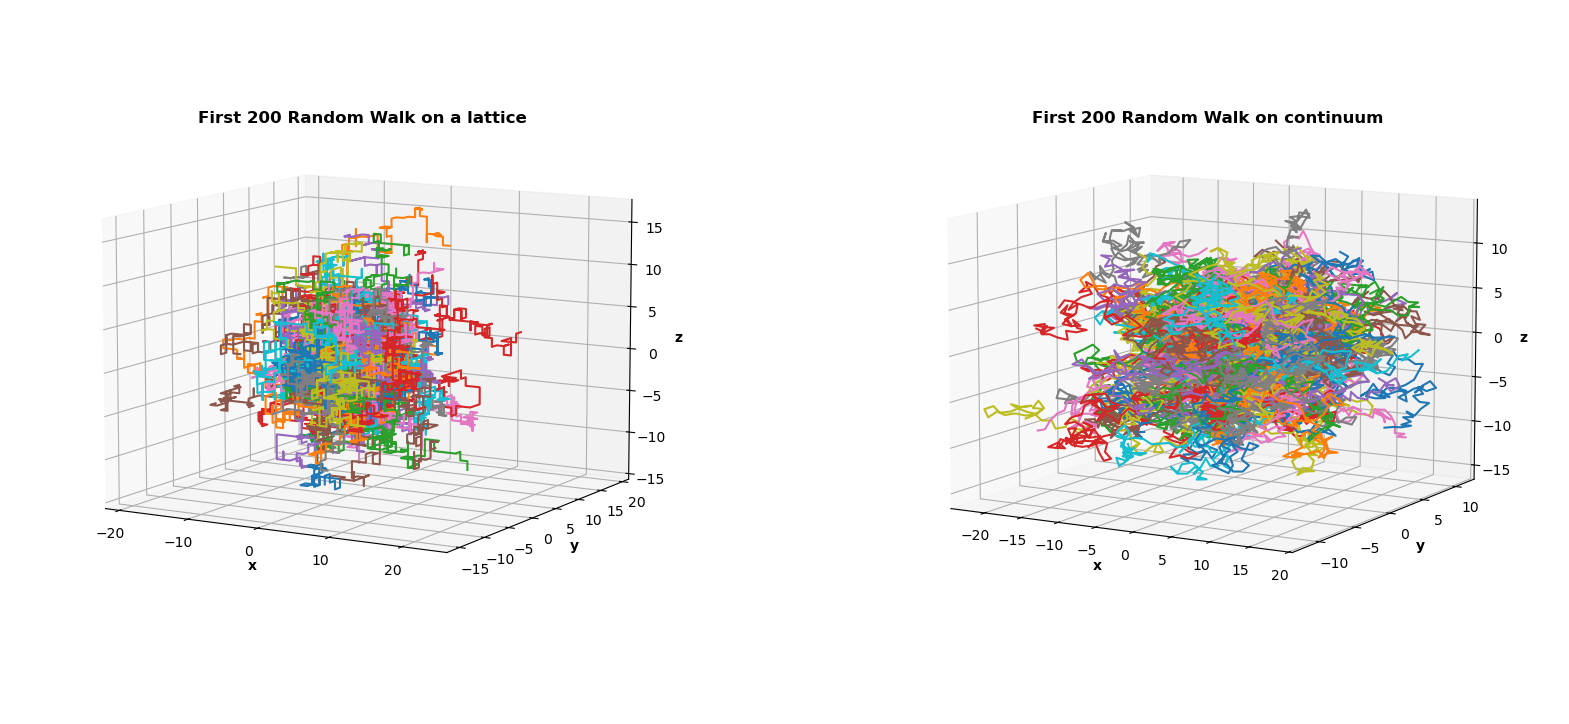

In [5]:
df=pd.read_csv('data/RW_lattice.csv')
crw=pd.read_csv('data/RW_continuous_lattice.csv')

fig=plt.figure(
    figsize=(20,10)
)
ax=fig.add_subplot(1, 2, 1, projection='3d')
ax.set_box_aspect(None, zoom=0.85)
for run in df['#rw'].unique()[:200]:
    dfr=df.loc[df['#rw']==run]
    ax.plot(dfr.x, dfr.y, dfr.z, '-', label=f'run={run}')
#plt.legend()
ax.set_xlabel('x', fontweight='bold')
ax.set_ylabel('y', fontweight='bold')
ax.set_zlabel('z', fontweight='bold')
#ax.ticks_params(fontweight='bold')
ax.view_init(elev=10)
ax.set_title('First 200 Random Walk on a lattice', fontweight='bold', y=0.9)

ax=fig.add_subplot(1,2,2, projection='3d')
ax.set_box_aspect(None, zoom=0.85)
for run in crw['#rw'].unique()[:200]:
    dfr=crw.loc[crw['#rw']==run]
    ax.plot(dfr.x, dfr.y, dfr.z, '-', label=f'run={run}')
#plt.legend()
ax.set_xlabel('x', fontweight='bold')
ax.set_ylabel('y', fontweight='bold')
ax.set_zlabel('z', fontweight='bold')
#ax.ticks_params(fontweight='bold')
ax.view_init(elev=10)
ax.set_title('First 200 Random Walk on continuum', fontweight='bold', y=0.9)
plt.show()
plt.show()


To compute the mean value of the explored distance of the Random Walk, $10^4$ relization of the RW were computed and distributed along 100 blocks on which it was calculated the progressive average at every step storing it as a matrix step x block

```C++

	//number of realizations
	int N=10000;
	
	//number of steps
	int M=100;
	
	//data block dimension
	int nblock=100;
	int L=N/nblock;
	
	
	out<<"#rw,step,x,y,z"<<endl;
	RW_lattice rw(1.);
	
	//2d vectors of shape (Nblocks, step)
	vector<vector<double>> avg(M, vector<double> (nblock, 0.));
	vector<vector<double>> av2(M, vector<double> (nblock, 0.));
	
	
	
	for(int block=0; block<nblock; ++block)
	{
		for(int l=0; l<L; ++l) // for each block make L RWs
		{	
				
			int run=L*block+l;
			
			/*******   new RW   *******/

			vector<double> point = rw.get_pos();
			// save initial step
			out <<run<<","<<rw.get_nstep()<<","
				<<point[0]<<","
				<<point[1]<<","
				<<point[2]<<endl;
			

			for (int k=0; k<M; ++k) //for on steps
			{
				rw.make_step();
				
				// save step
				point=rw.get_pos();
				out<<run<<","<<rw.get_nstep()
					<<","<<point[0]
					<<","<<point[1]
					<<","<<point[2]<<endl;
				
				//for each step update 
				// the average on nblock walks
				avg[k][block]+=sqrt(
					 point[0]*point[0]
					+point[1]*point[1]
					+point[2]*point[2]
				);
			}
			// reset the RW in pos 0 and set step to 0
			rw.reset_rw(); 
		}
		
		//performe mean and square mean
		for(int k=0; k<M; ++k)
		{
			avg[k][block]/=L;
			av2[k][block]=avg[k][block]*avg[k][block];
		}
	}	
	
	//save the RWs
	out.close();


	//init file
	stat_out<<"N,block,rN,err"<<endl;
	
	vector<vector<double>> sum(M, vector<double> (nblock, 0.));
	vector<vector<double>> su2(M, vector<double> (nblock, 0.));
	vector<vector<double>> err(M, vector<double> (nblock, 0.));
	// cumulative mean over blocks
	for(int k=0; k<M; ++k) //step iteration
	{
		for(int block=0; block<nblock; ++block)
		{
			for(int j=0; j<=block; ++j)
			{
				sum[k][block]+=avg[k][j];
				su2[k][block]+=av2[k][j];
			}
			sum[k][block]/=(block+1);
			su2[k][block]/=(block+1);
			err[k][block]=error(sum[k], su2[k], block);
		
			stat_out<<k<<","<<block<<","
				<<sum[k][block]<<","
				<<err[k][block]<<endl;		
		}
	}
	stat_out.close();
	
```

## Data Visualization
### Lattice RW

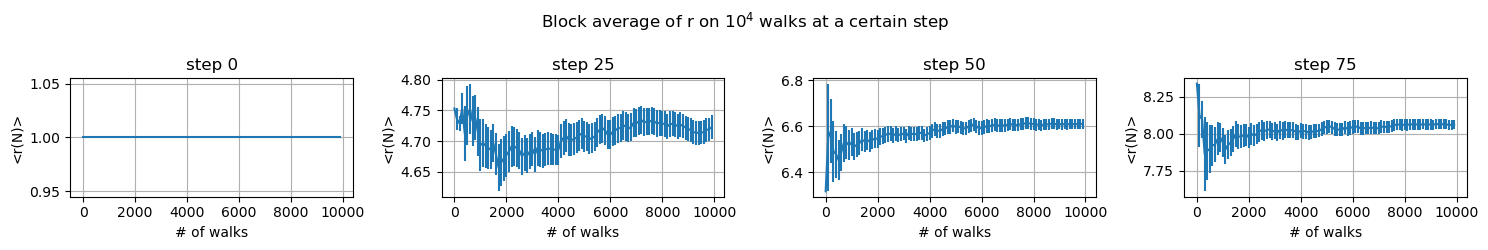

In [26]:
dfrn=pd.read_csv('data/RW_rn.csv')

fig, ax = plt.subplots(1, 4, figsize=(15, 2.5))
fig.suptitle('Block average of r on $10^4$ walks at a certain step')
for N in dfrn.N.unique()[::25]:
    dfn=dfrn.loc[dfrn.N==N]
    ax[N//25].set_title(f'step {N}')
    ax[N//25].errorbar(100*dfn.block, dfn.rN, yerr=dfn.err)
    ax[N//25].set_xlabel('# of walks')
    ax[N//25].set_ylabel('<r(N)>')
    ax[N//25].grid()
plt.tight_layout()
plt.show()

Taking the last block of every step the underlying figure show the diffusive behavior of the Random Walks $k\sqrt{N}$

In [27]:
from scipy.optimize import curve_fit

def diffuse(N, k:float):
    return k*np.sqrt(N)

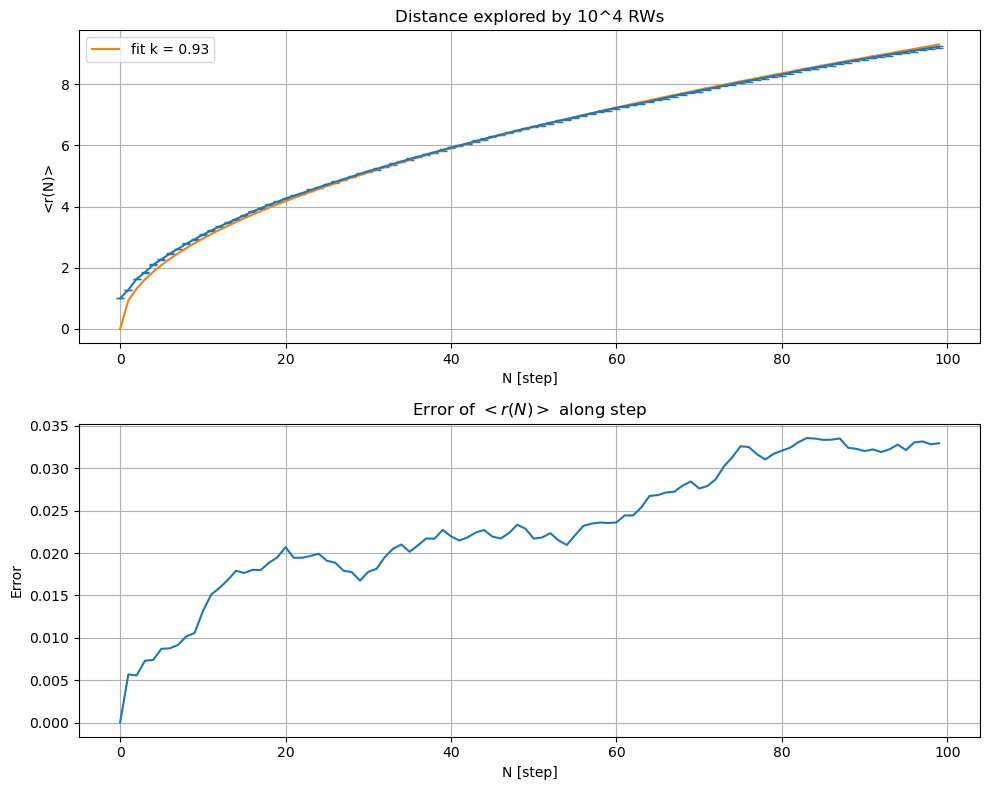

In [28]:
diff_m=dfrn.loc[dfrn.block==99].reset_index(drop=True) # last block values

# fit parameters
popt, pcov = curve_fit(diffuse, diff_m.N, diff_m.rN)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].errorbar(diff_m.N, diff_m.rN, yerr=diff_m.err, capsize=3)
ax[0].plot(diff_m.N, diffuse(diff_m.N, popt[0]), label=f'fit k = {"%.2f" % popt[0]}')
ax[0].grid(True)
ax[0].set_xlabel('N [step]')
ax[0].set_ylabel('<r(N)>')
ax[0].set_title('Distance explored by 10^4 RWs')
ax[0].legend()


ax[1].set_title('Error of $ < r(N) > $ along step')
ax[1].plot(diff_m.err)
ax[1].set_xlabel('N [step]')
ax[1].set_ylabel('Error')
ax[1].grid()

plt.tight_layout()
plt.show()

### Continuous RW

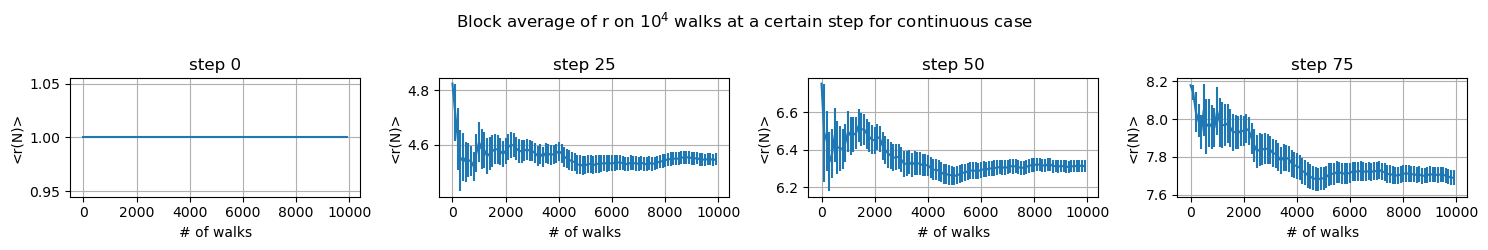

In [29]:
dfrn=pd.read_csv('data/RW_continuous_rn.csv')

fig, ax = plt.subplots(1, 4, figsize=(15, 2.5))
fig.suptitle('Block average of r on $10^4$ walks at a certain step for continuous case')
for N in dfrn.N.unique()[::25]:
    dfn=dfrn.loc[dfrn.N==N]
    ax[N//25].set_title(f'step {N}')
    ax[N//25].errorbar(100*dfn.block, dfn.rN, yerr=dfn.err)
    ax[N//25].set_xlabel('# of walks')
    ax[N//25].set_ylabel('<r(N)>')
    ax[N//25].grid()
plt.tight_layout()
plt.show()

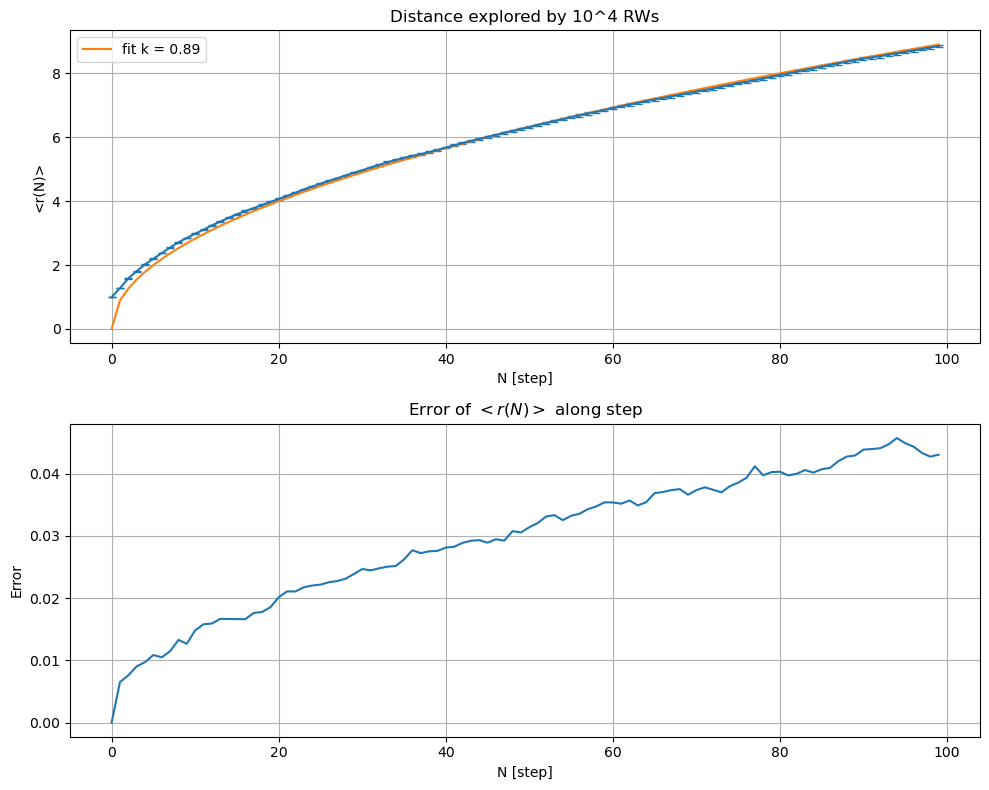

In [30]:
df=dfrn.loc[dfrn.block==99].reset_index(drop=True)


# fit parameters
popt, pcov = curve_fit(diffuse, df.N, df.rN)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].errorbar(df.N, df.rN, yerr=df.err, capsize=3)
ax[0].plot(diff_m.N, diffuse(diff_m.N, popt[0]), label=f'fit k = {"%.2f" % popt[0]}')
ax[0].grid(True)
ax[0].set_xlabel('N [step]')
ax[0].set_ylabel('<r(N)>')
ax[0].set_title('Distance explored by 10^4 RWs')
ax[0].legend()


ax[1].plot(df.err)
ax[1].set_xlabel('N [step]')
ax[1].set_ylabel('Error')
ax[1].set_title('Error of $ < r(N) > $ along step')
ax[1].grid()

plt.tight_layout()
plt.show()

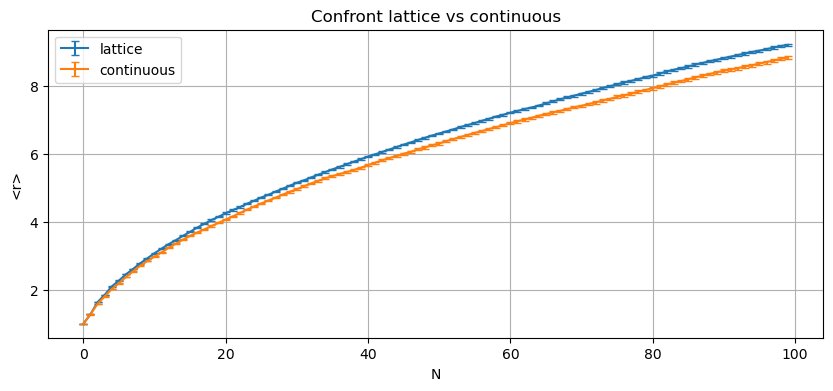

In [35]:
plt.figure(figsize=(10, 4))
plt.title('Confront lattice vs continuous')
plt.errorbar(diff_m.N, diff_m.rN, yerr=diff_m.err,capsize=3, label='lattice')
plt.errorbar(df.N, df.rN, yerr=df.err, capsize=3, label='continuous')
plt.legend()
plt.xlabel('N')
plt.ylabel('<r>')
plt.grid()
plt.show()